In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [9]:
df = pd.read_csv("cleaned_fact_water_samples.csv")
df.head()

,Sample_ID,Timestamp,Location_ID,Water_Temp_C,pH_Level,Turbidity_NTU,Dissolved_Oxygen_mgL,Microplastic_Count_per_m3,Dominant_Polymer,Dominant_Morphology,Average_Particle_Size_mm,Risk_Level
0,SMP-2026-0001,2026-01-01 00:00:00,LOC-107,9.2,7.38,33.32,10.62,552,PE,Fiber,0.06,High
1,SMP-2026-0002,2026-01-01 04:00:00,LOC-104,8.6,8.37,23.87,11.34,422,PS,Foam,0.21,High
2,SMP-2026-0003,2026-01-01 08:00:00,LOC-108,22.3,7.35,1.95,7.77,39,PET,Film,0.06,Low
3,SMP-2026-0004,2026-01-01 12:00:00,LOC-105,15.2,7.76,39.15,8.69,529,PS,Fiber,2.28,High
4,SMP-2026-0005,2026-01-01 16:00:00,LOC-107,10.5,7.41,3.38,11.15,87,PS,Foam,1.49,Low


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sample_ID                  1000 non-null   object 
 1   Timestamp                  1000 non-null   object 
 2   Location_ID                1000 non-null   object 
 3   Water_Temp_C               1000 non-null   float64
 4   pH_Level                   1000 non-null   float64
 5   Turbidity_NTU              1000 non-null   float64
 6   Dissolved_Oxygen_mgL       1000 non-null   float64
 7   Microplastic_Count_per_m3  1000 non-null   int64  
 8   Dominant_Polymer           1000 non-null   object 
 9   Dominant_Morphology        1000 non-null   object 
 10  Average_Particle_Size_mm   1000 non-null   float64
 11  Risk_Level                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [11]:
df.isnull().sum()

Sample_ID                    0
Timestamp                    0
Location_ID                  0
Water_Temp_C                 0
pH_Level                     0
Turbidity_NTU                0
Dissolved_Oxygen_mgL         0
Microplastic_Count_per_m3    0
Dominant_Polymer             0
Dominant_Morphology          0
Average_Particle_Size_mm     0
Risk_Level                   0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Risk_Level"].value_counts()

Risk_Level
Medium      428
High        324
Critical    125
Low         123
Name: count, dtype: int64

In [14]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day
df["Month"] = df["Timestamp"].dt.month
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

In [15]:
df[
    ["Timestamp", "Hour", "Day", "Month", "DayOfWeek"]
].head()

,Timestamp,Hour,Day,Month,DayOfWeek
0,2026-01-01 00:00:00,0,1,1,3
1,2026-01-01 04:00:00,4,1,1,3
2,2026-01-01 08:00:00,8,1,1,3
3,2026-01-01 12:00:00,12,1,1,3
4,2026-01-01 16:00:00,16,1,1,3


In [16]:
X = df[
    [
        "Location_ID",
        "Water_Temp_C",
        "pH_Level",
        "Turbidity_NTU",
        "Dissolved_Oxygen_mgL",
        "Dominant_Polymer",
        "Dominant_Morphology",
        "Average_Particle_Size_mm",
        "Hour",
        "Day",
        "Month",
        "DayOfWeek"
    ]
]
y = df["Microplastic_Count_per_m3"]

In [17]:
categorical_features = [
    "Location_ID",
    "Dominant_Polymer",
    "Dominant_Morphology"
]
numerical_features = [
    "Water_Temp_C",
    "pH_Level",
    "Turbidity_NTU",
    "Dissolved_Oxygen_mgL",
    "Average_Particle_Size_mm",
    "Hour",
    "Day",
    "Month",
    "DayOfWeek"
]

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [20]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [23]:
#creating random forest regression
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [24]:
#creating model pipeline 
model_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", rf_model)
    ]
)

In [25]:
#model training 
model_pipeline.fit(X_train, y_train)

C:\Users\KEERTHI\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Location_ID',
                                                   'Dominant_Polymer',
                                                   'Dominant_Morphology'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [26]:
#model prediction
y_pred = model_pipeline.predict(X_test)

In [27]:
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_results.head(10)

,Actual,Predicted
0,375,427.340000
1,433,318.593333
2,127,119.700000
3,297,328.460000
4,689,578.220000
5,279,181.140000
6,477,781.646667
7,199,177.403333
8,286,188.263333
9,36,33.326667


In [28]:
#model evaluation
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 124.08548333333334


In [30]:
#RMSE
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 166.0128196942433


In [32]:
#R² Score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.5146100588195893


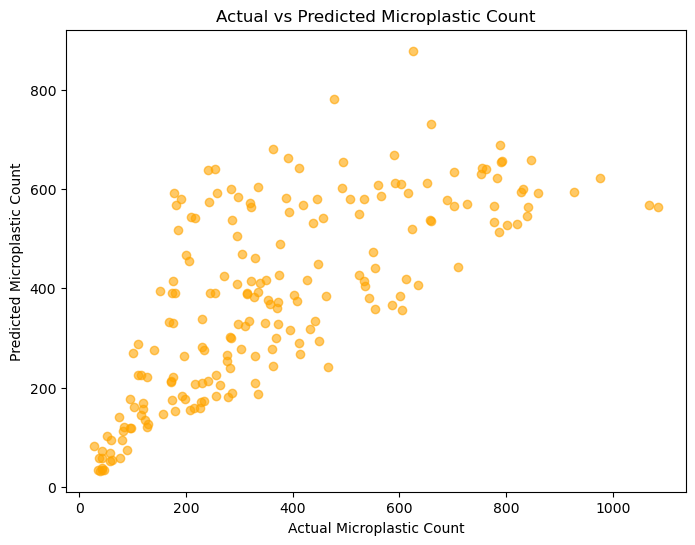

In [34]:
#Actual vs predicted Graph
plt.figure(figsize=(8, 6))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.6,color = 'orange'
)
plt.xlabel("Actual Microplastic Count")
plt.ylabel("Predicted Microplastic Count")
plt.title("Actual vs Predicted Microplastic Count")
plt.show()

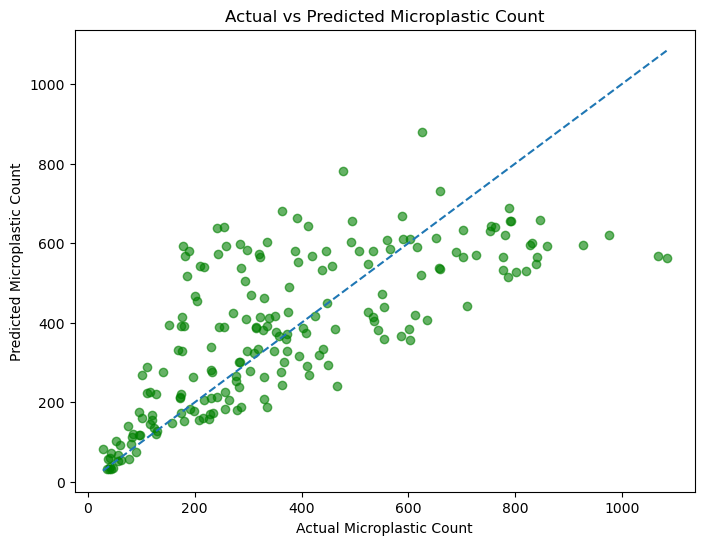

In [36]:
#ideal prediction line
plt.figure(figsize=(8, 6))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.6,color = 'green'
)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual Microplastic Count")
plt.ylabel("Predicted Microplastic Count")
plt.title("Actual vs Predicted Microplastic Count")
plt.show()

In [37]:
#Predicted Risk Level
def classify_risk(count):
    if count < 100:
        return "Low"
    elif count < 350:
        return "Medium"
    elif count < 700:
        return "High"
    else:
        return "Critical"

In [38]:
prediction_results["Predicted_Risk_Level"] = (
    prediction_results["Predicted"]
    .apply(classify_risk)
)

In [39]:
prediction_results.head(20)

,Actual,Predicted,Predicted_Risk_Level
0,375,427.340000,High
1,433,318.593333,Medium
2,127,119.700000,Medium
3,297,328.460000,Medium
4,689,578.220000,High
5,279,181.140000,Medium
6,477,781.646667,Critical
7,199,177.403333,Medium
8,286,188.263333,Medium
9,36,33.326667,Low


In [40]:
test_indices = X_test.index

In [41]:
ml_predictions = df.loc[
    test_indices,
    [
        "Sample_ID",
        "Location_ID",
        "Timestamp"
    ]
].copy()

In [42]:
ml_predictions["Actual_Microplastic_Count"] = (
    y_test.values
)
ml_predictions["Predicted_Microplastic_Count"] = (
    y_pred
)

In [43]:
ml_predictions["Predicted_Risk_Level"] = (
    ml_predictions[
        "Predicted_Microplastic_Count"
    ].apply(classify_risk)
)

In [44]:
ml_predictions["Prediction_Error"] = (
    ml_predictions["Actual_Microplastic_Count"]
    - ml_predictions["Predicted_Microplastic_Count"]
)

In [45]:
ml_predictions["Absolute_Error"] = abs(
    ml_predictions["Prediction_Error"]
)

In [46]:
ml_predictions.to_csv(
    "ml_predictions.csv",
    index=False
)

In [47]:
print("Prediction file created successfully!")

Prediction file created successfully!
